In [1]:
%cd /home/raman/school/CMPT_459/project/cmpt-459-project

/home/raman/school/CMPT_459/project/cmpt-459-project


/home/raman/school/CMPT_459/project/cmpt-459-project/cpython_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from utils.helpers import load_data, get_ticker_list
from utils.enums import Ticker, TimeFrame
import pandas as pd
from feature_selection.opt_thresh import optimize_threshold, optimize_all_features
from eda.correlation import plot_feature_deciles

In [3]:
data = load_data(Ticker.GC, TimeFrame.D)

In [4]:
data


,datetime,open,high,low,close,volume
timestamp,,,,,,
822960000,1996-01-30,408.8,410.5,405.8,409.0,68826
823046400,1996-01-31,406.5,408.8,405.0,408.5,38461
823132800,1996-02-01,409.2,414.0,408.7,413.7,63681
823219200,1996-02-02,415.0,420.2,414.5,417.7,255
823478400,1996-02-05,418.9,419.3,415.6,415.9,35478
...,...,...,...,...,...,...
1757894400,2025-09-15,3680.2,3724.9,3662.8,3719.0,189452
1757980800,2025-09-16,3720.3,3739.9,3711.8,3725.1,192295
1758067200,2025-09-17,3727.3,3744.0,3679.5,3717.8,256047


In [5]:
from feature_extraction.feature_extractor import extract_feature, extract_features_multi

In [6]:

#features = extract_feature(ticker=Ticker.CD)
features = extract_feature(ticker=Ticker.GC)

Running backtest features:   0%|          | 0/6467 [00:00<?, ?candles/s]/home/raman/school/CMPT_459/project/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
/home/raman/school/CMPT_459/project/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
Running backtest features: 100%|██████████| 6467/6467 [00:06<00:00, 1044.68candles/s

In [7]:
features

,open,high,low,close,volume,target,bollinger_band_D_bollinger_80_1.0,detrended_rsi_D_detrended_rsi_2_20_252,donchian_channel_10_D_donchian_10,donchian_channel_10_D_donchian_10_position,...,prev_return_D_log_return,prev_return_D_sign,prev_return_D_is_bullish,rsi_10_D_rsi_10,rsi_14_D_rsi_14,rsi_2_D_rsi_2,rsi_5_D_rsi_5,turtle_W_donchian_4,turtle_W_donchian_4_position,ticker
2000-01-04 00:00:00+00:00,289.5,289.5,280.0,283.7,30697,-0.020238,0.0,0.000000,0.0,0,...,0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-05 00:00:00+00:00,283.7,285.0,281.0,282.1,21621,-0.005656,0.0,0.000000,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-06 00:00:00+00:00,281.6,282.8,280.2,282.4,25448,0.002837,0.0,0.000000,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-07 00:00:00+00:00,282.5,284.5,282.0,282.9,19055,0.001415,0.0,0.000000,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-10 00:00:00+00:00,282.4,283.9,281.8,282.7,11266,0.001062,0.0,0.000000,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15 00:00:00+00:00,3680.2,3724.9,3662.8,3719.0,189452,0.010488,1.0,-14.634224,1.0,buy,...,0.003696,1.0,True,79.570014,75.891931,78.457146,82.491632,0,0,GC
2025-09-16 00:00:00+00:00,3720.3,3739.9,3711.8,3725.1,192295,0.001289,1.0,-1.797319,1.0,buy,...,0.010488,1.0,True,82.442640,78.264724,94.598359,87.858838,0,0,GC
2025-09-17 00:00:00+00:00,3727.3,3744.0,3679.5,3717.8,256047,-0.002552,1.0,0.479468,1.0,buy,...,0.001289,1.0,True,82.941332,78.687427,95.781293,88.671139,0,0,GC
2025-09-18 00:00:00+00:00,3692.5,3707.3,3660.5,3678.3,224128,-0.003853,1.0,-23.104927,1.0,buy,...,-0.002552,-1.0,False,79.922841,76.763455,62.842535,80.604126,0,0,GC


In [8]:
# plot_feature_deciles(features)

In [9]:
#optimize_all_features(features, 'target', 400)

In [10]:
from feature_selection.perm_test import permutation_test

In [11]:
features = features.drop(columns=['open', 'high', 'low', 'close', 'volume'])

In [12]:
features

,target,bollinger_band_D_bollinger_80_1.0,detrended_rsi_D_detrended_rsi_2_20_252,donchian_channel_10_D_donchian_10,donchian_channel_10_D_donchian_10_position,donchian_channel_160_D_donchian_160,donchian_channel_160_D_donchian_160_position,donchian_channel_20_D_donchian_20,donchian_channel_20_D_donchian_20_position,donchian_channel_4_W_donchian_4,...,prev_return_D_log_return,prev_return_D_sign,prev_return_D_is_bullish,rsi_10_D_rsi_10,rsi_14_D_rsi_14,rsi_2_D_rsi_2,rsi_5_D_rsi_5,turtle_W_donchian_4,turtle_W_donchian_4_position,ticker
2000-01-04 00:00:00+00:00,-0.020238,0.0,0.000000,0.0,0,0.0,0.0,0,0.0,0.0,...,0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-05 00:00:00+00:00,-0.005656,0.0,0.000000,1.0,1.0,1.0,0.0,0,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-06 00:00:00+00:00,0.002837,0.0,0.000000,1.0,1.0,1.0,0.0,0,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-07 00:00:00+00:00,0.001415,0.0,0.000000,1.0,1.0,1.0,0.0,0,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
2000-01-10 00:00:00+00:00,0.001062,0.0,0.000000,1.0,1.0,1.0,0.0,0,1.0,1.0,...,50.0,0,0.0,0.000000,0.000000,0.000000,0,0,0,GC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15 00:00:00+00:00,0.010488,1.0,-14.634224,1.0,buy,1.0,buy,1.0,buy,1.0,...,0.003696,1.0,True,79.570014,75.891931,78.457146,82.491632,0,0,GC
2025-09-16 00:00:00+00:00,0.001289,1.0,-1.797319,1.0,buy,1.0,buy,1.0,buy,1.0,...,0.010488,1.0,True,82.442640,78.264724,94.598359,87.858838,0,0,GC
2025-09-17 00:00:00+00:00,-0.002552,1.0,0.479468,1.0,buy,1.0,buy,1.0,buy,1.0,...,0.001289,1.0,True,82.941332,78.687427,95.781293,88.671139,0,0,GC
2025-09-18 00:00:00+00:00,-0.003853,1.0,-23.104927,1.0,buy,1.0,buy,1.0,buy,1.0,...,-0.002552,-1.0,False,79.922841,76.763455,62.842535,80.604126,0,0,GC


In [13]:
#permutation_test(features, 'target', 0.05)

In [14]:
from feature_selection.cross_val import cross_validate_features, walkforward_validate_features

cross_validate_features(features, 'target', n_splits=5, floor=0.05, exclude_cols=None, verbose=True)

CROSS-VALIDATION WITH OPTIMIZE_THRESHOLD
Target column: target
Number of folds: 5
Floor (min fraction to trade): 0.05

Number of features: 43
Number of samples: 6467
  Skipping fold 0 for 'donchian_channel_160_D_donchian_160': insufficient samples (n_high=1293, n_low=1)
  Skipping fold 0 for 'donchian_channel_4_W_donchian_4': insufficient samples (n_high=1293, n_low=1)
  Skipping fold 1 for 'donchian_channel_4_W_donchian_4': insufficient samples (n_high=1294, n_low=0)
  Skipping fold 2 for 'donchian_channel_4_W_donchian_4': insufficient samples (n_high=1293, n_low=0)
  Skipping fold 3 for 'donchian_channel_4_W_donchian_4': insufficient samples (n_high=1293, n_low=0)
  Skipping fold 4 for 'donchian_channel_4_W_donchian_4': insufficient samples (n_high=1293, n_low=0)
  Skipping 'donchian_channel_4_W_donchian_4': no valid folds (all had insufficient samples)
Processing feature 10/43: donchian_channel_4_W_donchian_4_position
  Skipping fold 1 for 'donchian_channel_50_W_donchian_50': insuff

,feature,n_valid_folds,mean_pf_high,std_pf_high,mean_pf_low,std_pf_low,mean_pf_best,std_pf_best,mean_n_high,mean_n_low,in_sample_pf_high,in_sample_pf_low,in_sample_pf_best
0,moving_avg_diff_4_8_D_ma_difference_4_8_4,5,1.263415,0.173074,1.176883,0.259704,1.349941,0.195430,76.80,86.60,1.312237,1.169842,1.312237
1,moving_avg_diff_5_50_D_ma_difference_5_50_5,5,1.033208,0.126188,1.240450,0.428952,1.320216,0.389339,223.20,355.40,1.327534,1.022589,1.327534
2,moving_avg_diff_8_32_D_ma_difference_8_32_8,5,1.115054,0.163575,1.192421,0.228363,1.313551,0.166287,325.80,426.80,1.416280,1.046530,1.416280
3,moving_avg_diff_4_16_D_ma_difference_4_16_4,5,0.919839,0.147084,1.288958,0.309822,1.312226,0.291767,231.20,81.80,1.096725,1.196051,1.196051
4,moving_avg_diff_16_32_D_ma_difference_16_32_16,5,1.119282,0.128596,1.187319,0.245823,1.311264,0.166962,449.00,784.80,1.406924,1.022843,1.406924
5,moving_avg_diff_16_64_D_ma_difference_16_64_16,5,1.028769,0.023721,1.164553,0.163996,1.197577,0.104428,682.20,170.20,1.023470,1.214795,1.214795
6,moving_avg_diff_64_128_D_ma_difference_64_128_64,5,0.990173,0.122298,1.137300,0.333941,1.187628,0.264590,569.00,106.60,1.083196,1.211691,1.211691
7,moving_avg_diff_64_256_D_ma_difference_64_256_64,4,0.944298,0.106504,1.070687,0.332756,1.179590,0.218121,526.00,158.75,1.069204,1.137400,1.137400
8,moving_avg_diff_8_16_D_ma_difference_8_16_8,5,0.979404,0.049045,1.142156,0.303312,1.179215,0.273622,110.60,173.80,1.350789,1.049673,1.350789
9,moving_avg_diff_32_128_D_ma_difference_32_128_32,4,1.011366,0.031435,1.092525,0.211936,1.138428,0.149496,693.25,125.25,1.056011,1.138271,1.138271


WALK-FORWARD VALIDATION WITH OPTIMIZE_THRESHOLD
Target column: target
Training period: 2000-01-01 00:00:00 to 2010-01-01 00:00:00
Test step: 252 days
Number of steps: 9
Floor (min fraction to trade): 0.5

Number of features: 43
Total samples: 6467


Processing feature 1/43: bollinger_band_D_bollinger_80_1.0
  Step 0: Train=2507, Test=173
  Valid steps: 9/9, Mean PF: 0.99

Processing feature 2/43: detrended_rsi_D_detrended_rsi_2_20_252
  Step 0: Train=2507, Test=173
  Valid steps: 9/9, Mean PF: 1.09

Processing feature 3/43: donchian_channel_10_D_donchian_10
  Step 0: Train=2507, Test=173
  Valid steps: 9/9, Mean PF: 1.05

Processing feature 4/43: donchian_channel_10_D_donchian_10_position
  Step 0: Train=2507, Test=173

Processing feature 5/43: donchian_channel_160_D_donchian_160
  Step 0: Train=2507, Test=173
  Valid steps: 9/9, Mean PF: 0.98

Processing feature 6/43: donchian_channel_160_D_donchian_160_position
  Step 0: Train=2507, Test=173

Processing feature 7/43: donchian_channel

(                                             feature  n_valid_steps  \
 0   moving_avg_diff_32_128_D_ma_difference_32_128_32              9   
 1   moving_avg_diff_10_100_D_ma_difference_10_100_10              9   
 2          moving_avg_diff_2_8_D_ma_difference_2_8_2              9   
 3                           prev_return_D_log_return              9   
 4                               prev_return_D_return              9   
 5             detrended_rsi_D_detrended_rsi_2_20_252              9   
 6          moving_avg_diff_4_8_D_ma_difference_4_8_4              9   
 7        moving_avg_diff_4_16_D_ma_difference_4_16_4              9   
 8                                      rsi_5_D_rsi_5              9   
 9        moving_avg_diff_8_32_D_ma_difference_8_32_8              9   
 10       moving_avg_diff_5_50_D_ma_difference_5_50_5              9   
 11                          prev_return_D_is_bullish              9   
 12                                prev_return_D_sign           

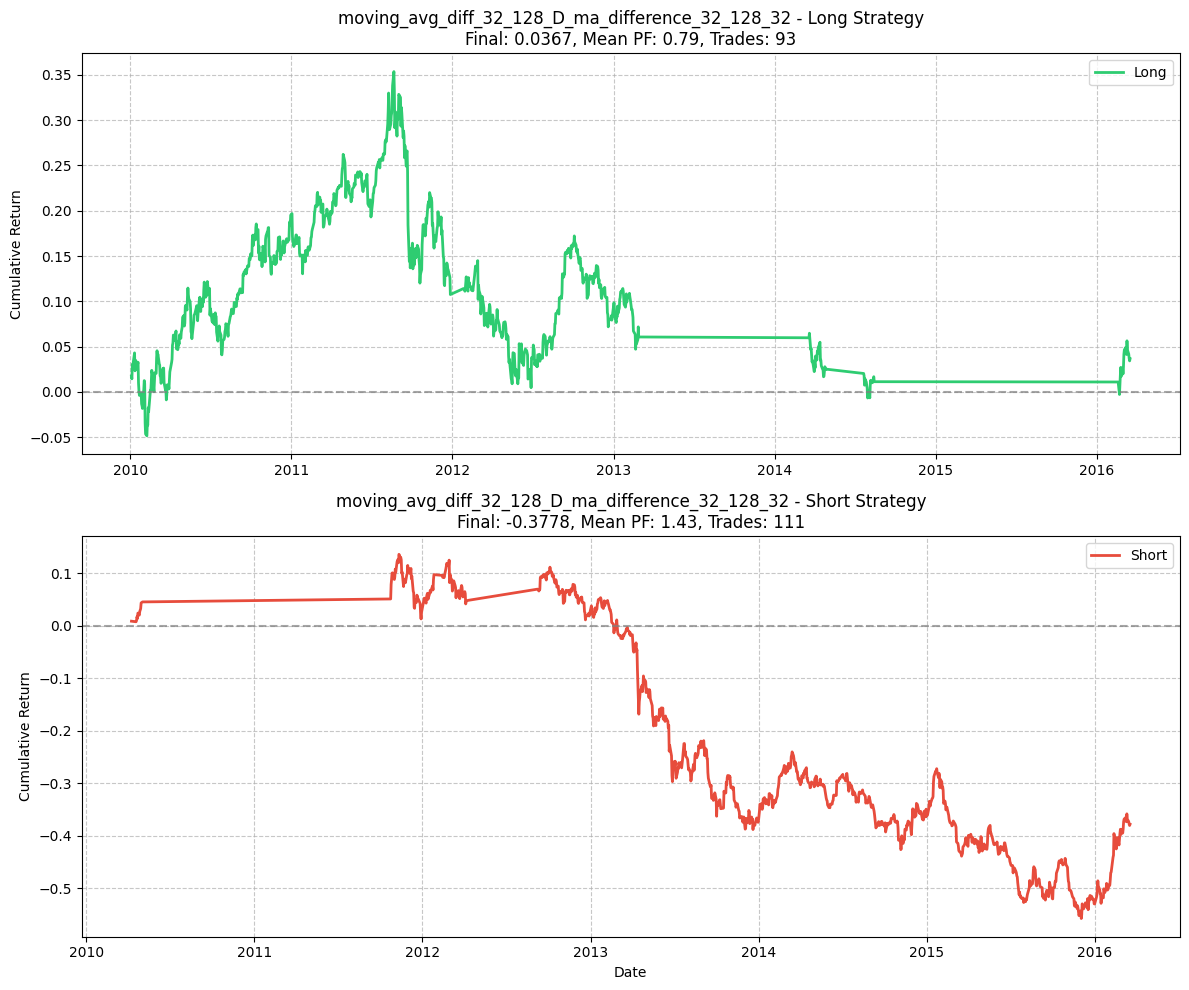

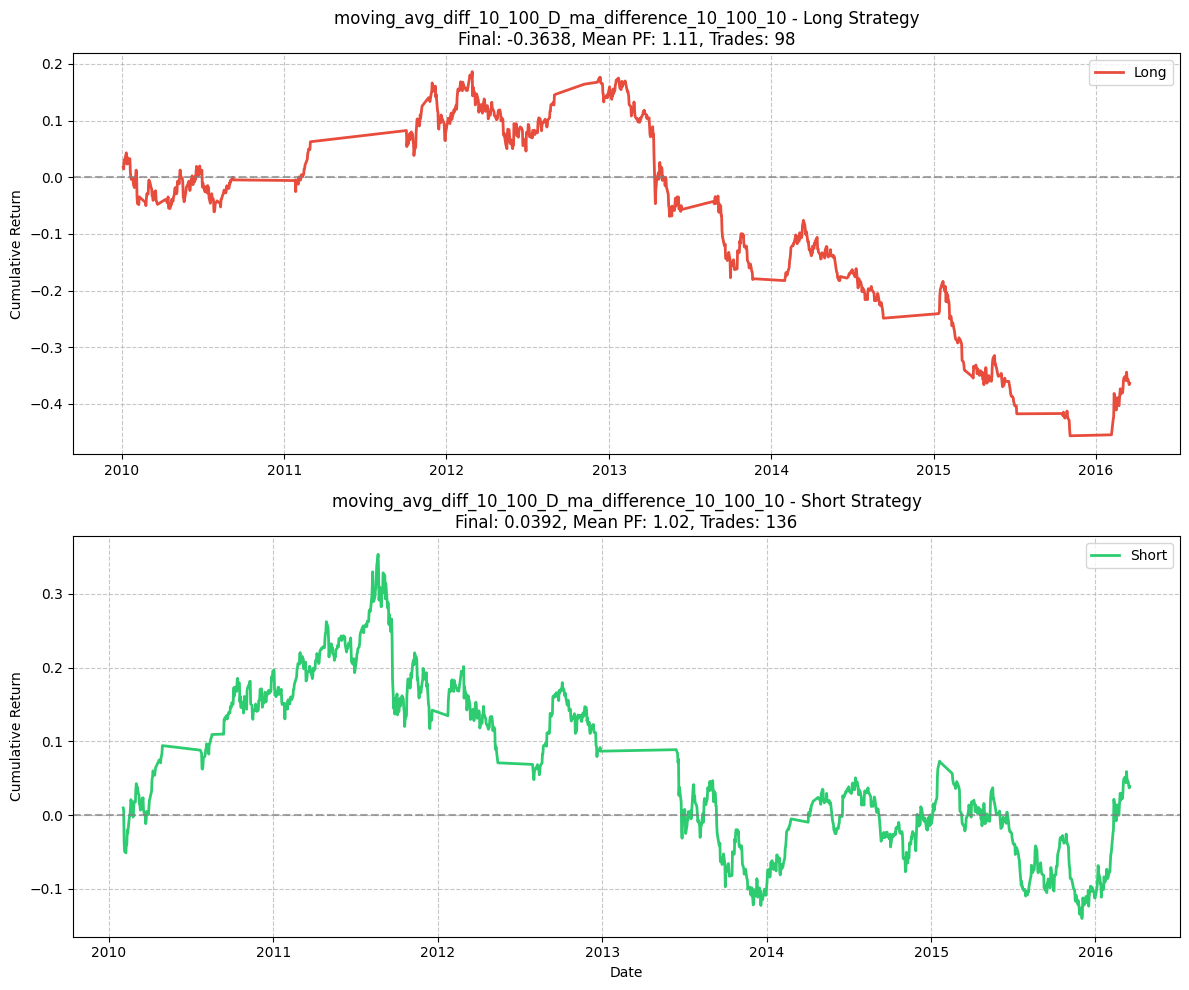

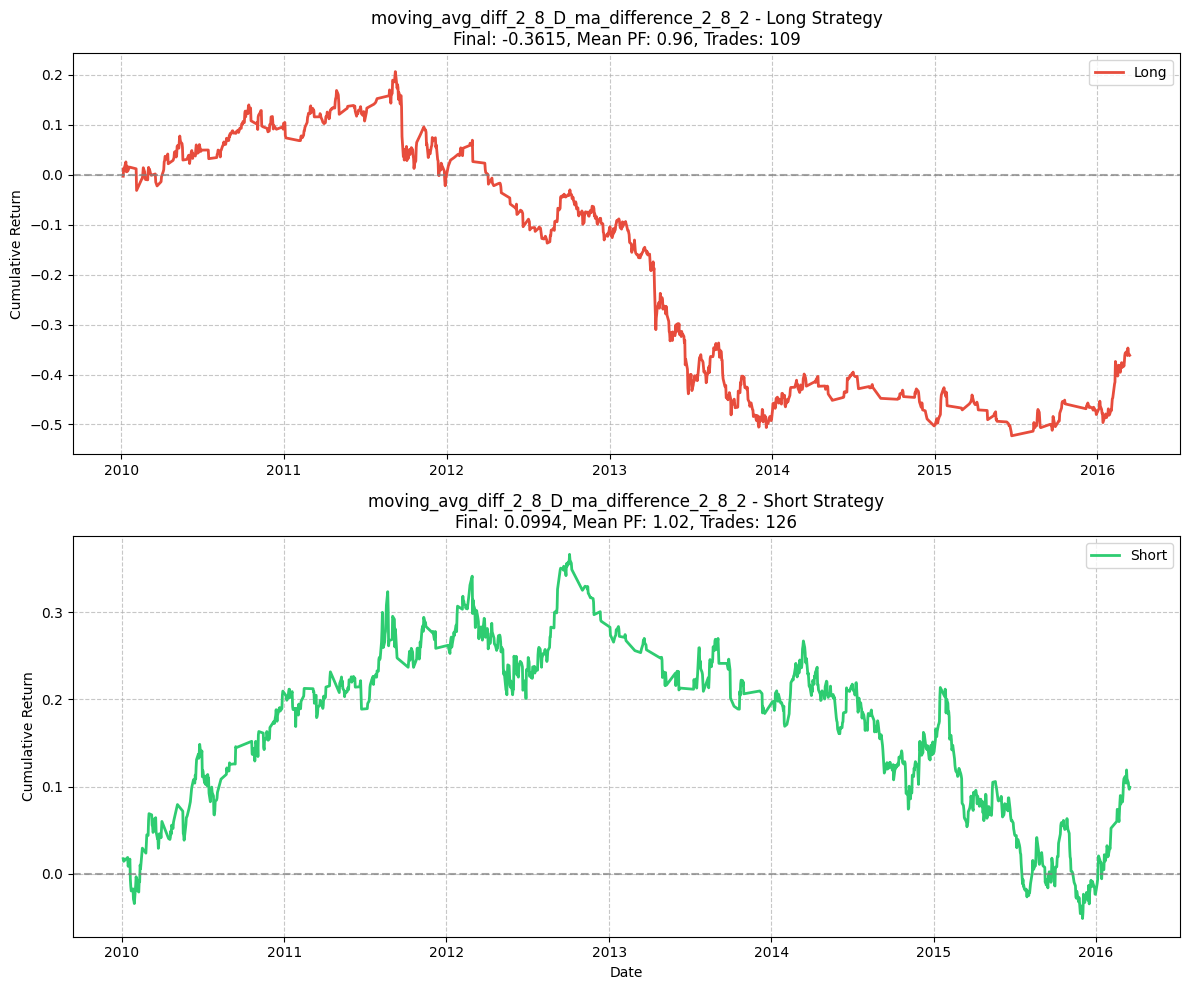

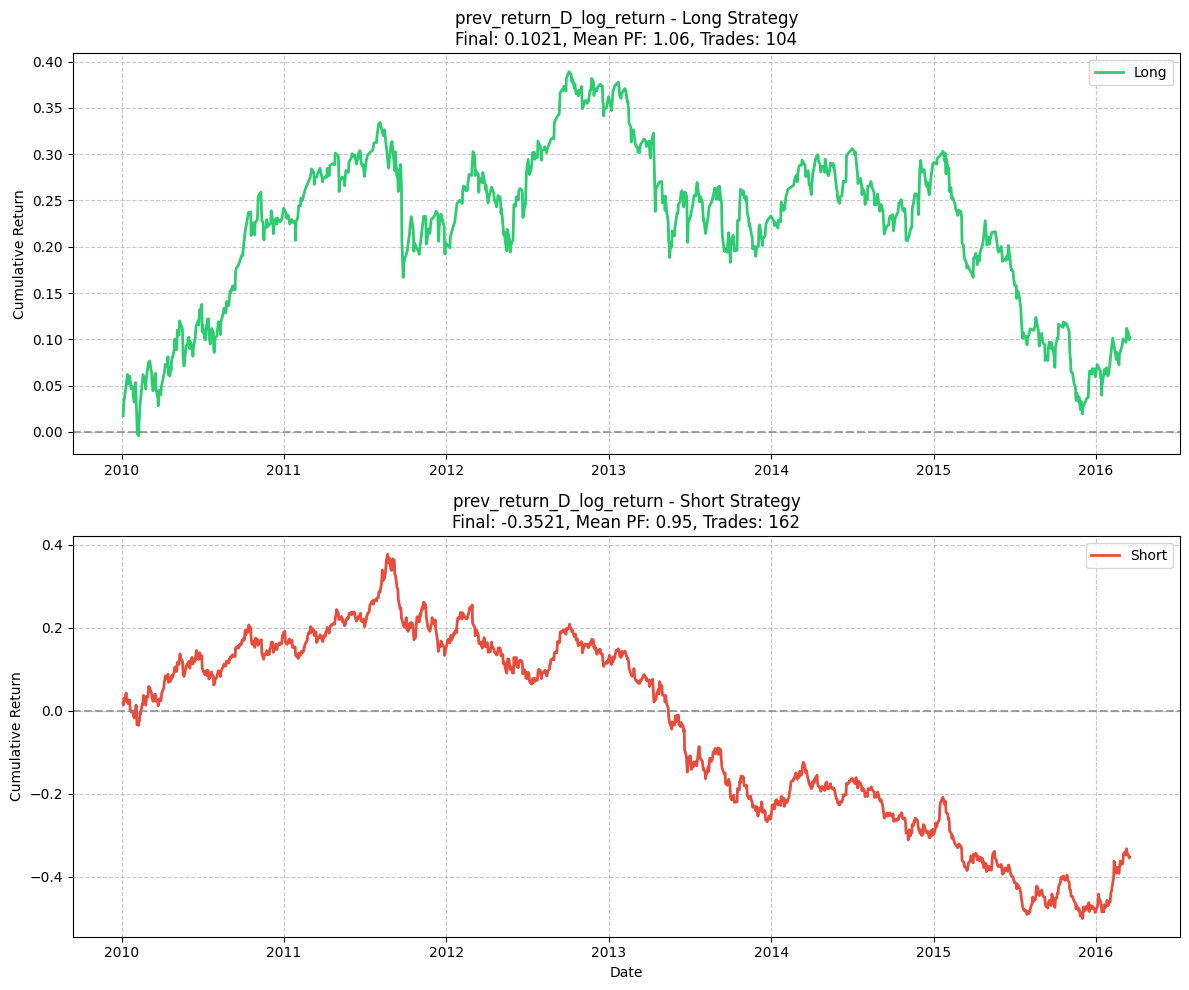

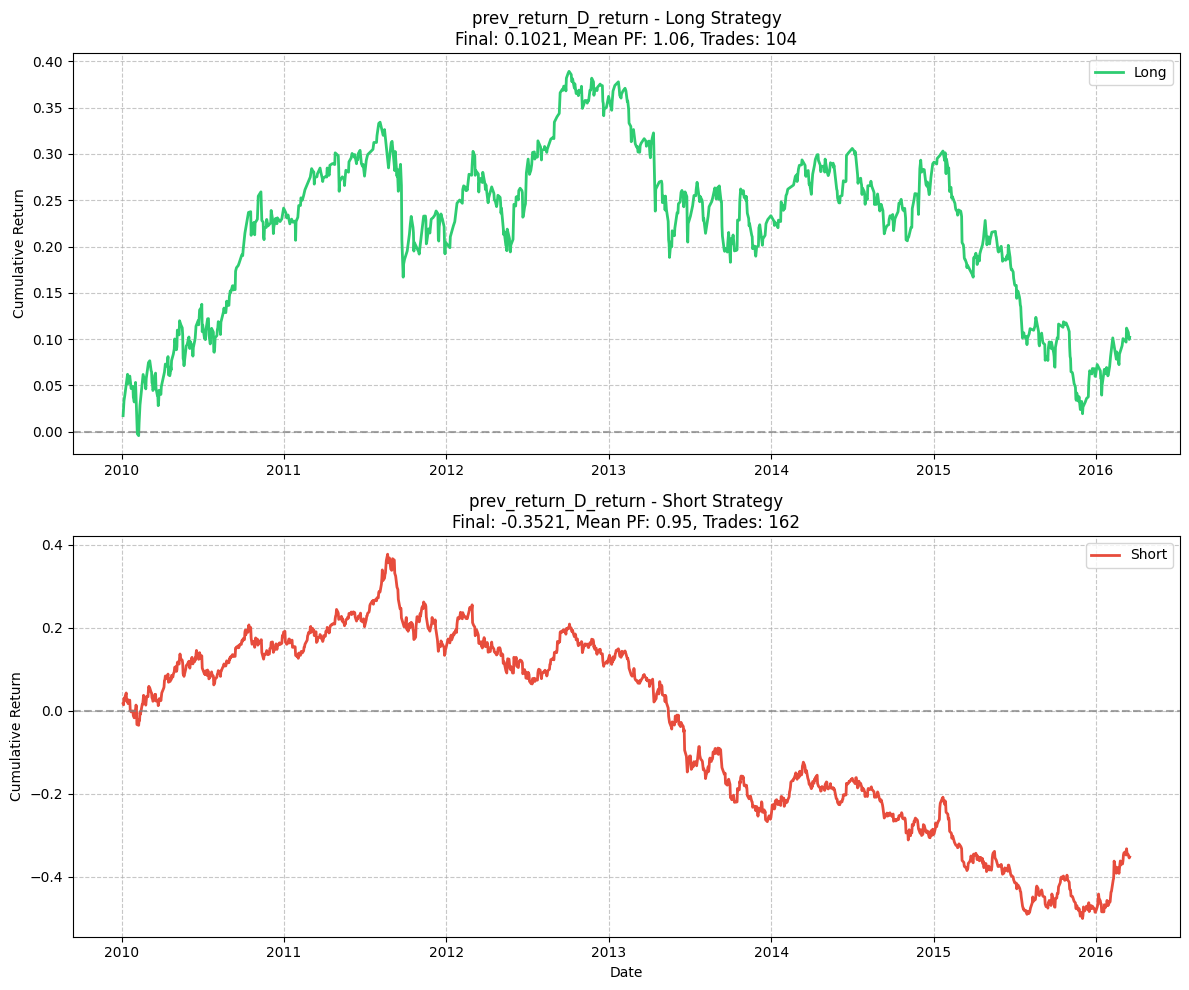

In [ ]:
from datetime import datetime

walkforward_validate_features(features, 'target', datetime(2000, 1, 1), datetime(2010, 1, 1), 252, 9, 0.05)